In [62]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

In [63]:
# ============================================================
# 프로젝트 경로 설정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정
# ============================================================

ROOT = Path(r"C:\Users\joon5\Documents\github\Anti-Churn-Committee")

DATA_RAW_DIR = ROOT / "data" / "raw"
DATA_PROCESSED_DIR = ROOT / "data" / "processed"

USER_PROFILE_FILE = "01_User_Profile.csv"
EVENT_LOG_FILE = "02_Event_Log.csv"

USER_PROFILE_PATH = DATA_RAW_DIR / USER_PROFILE_FILE
EVENT_LOG_PATH = DATA_RAW_DIR / EVENT_LOG_FILE

print("USER_PROFILE_PATH:", USER_PROFILE_PATH)
print("EVENT_LOG_PATH   :", EVENT_LOG_PATH)

USER_PROFILE_PATH: C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\raw\01_User_Profile.csv
EVENT_LOG_PATH   : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\raw\02_Event_Log.csv


In [64]:
df_raw01 = pd.read_csv(USER_PROFILE_PATH)
df_raw02 = pd.read_csv(EVENT_LOG_PATH)

print("df_raw01 shape:", df_raw01.shape)
print("df_raw02 shape:", df_raw02.shape)

display(df_raw01.head())
display(df_raw02.head())

df_raw01 shape: (12500, 6)
df_raw02 shape: (1757262, 5)


,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자
0,U0000001,2025-01-25,오가닉,iOS,True,NaN
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24
2,U0000003,2025-05-14,오가닉,iOS,False,NaN
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성


In [65]:
# ============================================================
# 원본 데이터 구조 확인
# ============================================================

print("User_Profile 컬럼")
print(df_raw01.columns.tolist())

print("\nEvent_Log 컬럼")
print(df_raw02.columns.tolist())

print("\nUser_Profile 결측치")
display(df_raw01.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nEvent_Log 결측치")
display(df_raw02.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\n중복 확인")
print("User_Profile 전체 중복 행:", df_raw01.duplicated().sum())
print("Event_Log 전체 중복 행    :", df_raw02.duplicated().sum())
print("User_Profile User_ID 중복 :", df_raw01.duplicated(subset=["User_ID"]).sum())

User_Profile 컬럼
['User_ID', '가입일자', '가입경로', '기기', '알림수신동의여부', '알림수신동의_변경일자']

Event_Log 컬럼
['User_ID', 'Event_Time', 'Event_Type', 'Session_ID', '알림_유형']

User_Profile 결측치


,missing_count
알림수신동의_변경일자,10524
가입경로,137
기기,121
알림수신동의여부,116
가입일자,0
User_ID,0



Event_Log 결측치


,missing_count
알림_유형,1538380
Session_ID,241502
Event_Type,26456
User_ID,0
Event_Time,0



중복 확인
User_Profile 전체 중복 행: 0
Event_Log 전체 중복 행    : 0
User_Profile User_ID 중복 : 0


In [66]:
# ============================================================
# 1. 기본 전처리
# ============================================================

user_profile = df_raw01.copy()
event_log = df_raw02.copy()

# 컬럼명 공백 제거
user_profile.columns = user_profile.columns.str.strip()
event_log.columns = event_log.columns.str.strip()

# 문자열 값 공백 제거
user_text_cols = user_profile.select_dtypes(include=["object", "string"]).columns
event_text_cols = event_log.select_dtypes(include=["object", "string"]).columns

user_profile[user_text_cols] = user_profile[user_text_cols].apply(lambda col: col.astype("string").str.strip())
event_log[event_text_cols] = event_log[event_text_cols].apply(lambda col: col.astype("string").str.strip())

# User_ID 타입 통일
user_profile["User_ID"] = user_profile["User_ID"].astype("string")
event_log["User_ID"] = event_log["User_ID"].astype("string")

# 날짜 변환
user_profile["가입일자"] = pd.to_datetime(user_profile["가입일자"], errors="coerce")
user_profile["알림수신동의_변경일자"] = pd.to_datetime(user_profile["알림수신동의_변경일자"], errors="coerce")
event_log["Event_Time"] = pd.to_datetime(event_log["Event_Time"], errors="coerce")

# 분석에 자주 쓸 날짜/월 컬럼
user_profile["가입일"] = user_profile["가입일자"].dt.normalize()
user_profile["가입월"] = user_profile["가입일자"].dt.to_period("M").astype("string")

event_log["Event_Date"] = event_log["Event_Time"].dt.normalize()
event_log["Event_Month"] = event_log["Event_Time"].dt.to_period("M").astype("string")
event_log["Event_Hour"] = event_log["Event_Time"].dt.hour

print("user_profile shape:", user_profile.shape)
print("event_log shape   :", event_log.shape)

user_profile shape: (12500, 8)
event_log shape   : (1757262, 8)


In [67]:
# ============================================================
# 2. 데이터 품질 확인용 플래그
# ============================================================

issue_start_date = pd.Timestamp("2025-03-10")
issue_end_date = pd.Timestamp("2025-03-14")

data_start_date = event_log["Event_Date"].min()
data_end_date = event_log["Event_Date"].max()

# 장애 기간 여부
user_profile["is_signup_issue_period"] = user_profile["가입일"].between(issue_start_date, issue_end_date)
event_log["is_event_issue_period"] = event_log["Event_Date"].between(issue_start_date, issue_end_date)

# Event_Type 결측은 삭제하지 않고 표시만 남김
event_log["Event_Type_missing"] = event_log["Event_Type"].isna()
event_log["Event_Type"] = event_log["Event_Type"].fillna("알수없음")

# Session_ID 결측도 일단 표시만 남김
# 알림 이벤트는 앱 밖에서 발생하므로 Session_ID가 없는 것이 자연스러울 수 있음
event_log["Session_ID_missing"] = event_log["Session_ID"].isna()

notification_events = ["알림수신", "알림오픈"]
event_log["is_notification_event"] = event_log["Event_Type"].isin(notification_events)

print("데이터 기간:", data_start_date, "~", data_end_date)
print("장애 기간:", issue_start_date.date(), "~", issue_end_date.date())

print("\nEvent_Type 결측 수:", event_log["Event_Type_missing"].sum())
print("Session_ID 결측 수:", event_log["Session_ID_missing"].sum())

데이터 기간: 2025-01-01 00:00:00 ~ 2025-06-30 00:00:00
장애 기간: 2025-03-10 ~ 2025-03-14

Event_Type 결측 수: 26456
Session_ID 결측 수: 241502


In [68]:
# ============================================================
# 3. User_Profile 기준으로 이벤트 로그 존재 여부 확인
# ============================================================

event_user_list = event_log["User_ID"].dropna().unique()

user_profile["has_event_log"] = user_profile["User_ID"].isin(event_user_list)
user_profile["is_no_event_user"] = ~user_profile["has_event_log"]
user_profile["is_no_event_issue_signup_user"] = user_profile["is_no_event_user"] & user_profile["is_signup_issue_period"]

quality_summary = pd.DataFrame({
    "항목": [
        "전체 가입자 수",
        "전체 이벤트 로그 수",
        "Event_Log에 존재하는 사용자 수",
        "프로필에는 있지만 이벤트 로그에는 없는 사용자 수",
        "로그 없는 사용자 중 장애기간 가입자 수",
        "장애기간 가입자 수",
        "장애기간 이벤트 수",
        "Event_Type 결측 이벤트 수",
        "Session_ID 결측 이벤트 수",
    ],
    "값": [
        user_profile["User_ID"].nunique(),
        len(event_log),
        event_log["User_ID"].nunique(),
        int(user_profile["is_no_event_user"].sum()),
        int(user_profile["is_no_event_issue_signup_user"].sum()),
        int(user_profile["is_signup_issue_period"].sum()),
        int(event_log["is_event_issue_period"].sum()),
        int(event_log["Event_Type_missing"].sum()),
        int(event_log["Session_ID_missing"].sum()),
    ]
})

display(quality_summary)

,항목,값
0,전체 가입자 수,12500
1,전체 이벤트 로그 수,1757262
2,Event_Log에 존재하는 사용자 수,12453
3,프로필에는 있지만 이벤트 로그에는 없는 사용자 수,47
4,로그 없는 사용자 중 장애기간 가입자 수,47
5,장애기간 가입자 수,341
6,장애기간 이벤트 수,20862
7,Event_Type 결측 이벤트 수,26456
8,Session_ID 결측 이벤트 수,241502


# 프로필과 이벤트 로그 연결

In [69]:
# ============================================================
# 1. 이벤트 로그에 가입 정보 붙이기
# ============================================================

profile_cols = [
    "User_ID",
    "가입일자",
    "가입일",
    "가입월",
    "가입경로",
    "기기",
    "알림수신동의여부",
    "is_signup_issue_period",
]

event_log = event_log.merge(
    user_profile[profile_cols],
    on="User_ID",
    how="left",
)

event_log["가입후경과일"] = (event_log["Event_Date"] - event_log["가입일"]).dt.days
event_log["is_event_before_signup"] = event_log["가입후경과일"] < 0
event_log["is_profile_missing_user"] = event_log["가입일"].isna()

print("프로필에 없는 Event_Log 사용자 수:", event_log.loc[event_log["is_profile_missing_user"], "User_ID"].nunique())
print("가입일보다 먼저 발생한 이벤트 수:", event_log["is_event_before_signup"].sum())

display(event_log.head())

프로필에 없는 Event_Log 사용자 수: 0
가입일보다 먼저 발생한 이벤트 수: 0


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형,Event_Date,Event_Month,Event_Hour,is_event_issue_period,Event_Type_missing,Session_ID_missing,is_notification_event,가입일자,가입일,가입월,가입경로,기기,알림수신동의여부,is_signup_issue_period,가입후경과일,is_event_before_signup,is_profile_missing_user
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,<NA>,2025-01-25,2025-01,7,False,False,False,False,2025-01-25,2025-01-25,2025-01,오가닉,iOS,True,False,0,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,<NA>,2025-01-25,2025-01,7,False,False,False,False,2025-01-25,2025-01-25,2025-01,오가닉,iOS,True,False,0,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,<NA>,2025-01-25,2025-01,7,False,False,False,False,2025-01-25,2025-01-25,2025-01,오가닉,iOS,True,False,0,False,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,<NA>,2025-01-25,2025-01,7,False,False,False,False,2025-01-25,2025-01-25,2025-01,오가닉,iOS,True,False,0,False,False
4,U0000001,2025-01-25 20:30:00,알림수신,<NA>,광고성,2025-01-25,2025-01,20,False,False,True,True,2025-01-25,2025-01-25,2025-01,오가닉,iOS,True,False,0,False,False


# 4. 사용자 단위 요약 만들기

In [70]:
# ============================================================
# 1. 이벤트 종류별 간단 플래그
# ============================================================

event_log["is_app_open"] = event_log["Event_Type"].eq("앱실행")
event_log["is_onboarding_complete"] = event_log["Event_Type"].eq("온보딩_완료")
event_log["is_challenge_event"] = event_log["Event_Type"].isin(["챌린지_탐색", "챌린지참여"])
event_log["is_notification_open"] = event_log["Event_Type"].eq("알림오픈")
event_log["is_notification_receive"] = event_log["Event_Type"].eq("알림수신")

In [71]:
# ============================================================
# 2. 사용자 단위 요약 테이블
# ============================================================

event_count_summary = (
    event_log
    .groupby("User_ID")
    .agg(
        전체이벤트수=("Event_Type", "count"),
        앱실행수=("is_app_open", "sum"),
        온보딩완료수=("is_onboarding_complete", "sum"),
        챌린지경험수=("is_challenge_event", "sum"),
        알림수신수=("is_notification_receive", "sum"),
        알림오픈수=("is_notification_open", "sum"),
        최초이벤트일=("Event_Date", "min"),
        마지막이벤트일=("Event_Date", "max"),
    )
    .reset_index()
)

first_app_open = (
    event_log.loc[event_log["is_app_open"]]
    .groupby("User_ID")["Event_Date"]
    .min()
    .rename("최초_앱실행일")
    .reset_index()
)

first_onboarding = (
    event_log.loc[event_log["is_onboarding_complete"]]
    .groupby("User_ID")["Event_Date"]
    .min()
    .rename("최초_온보딩완료일")
    .reset_index()
)

first7_summary = (
    event_log.loc[event_log["가입후경과일"].between(0, 6)]
    .groupby("User_ID")
    .agg(
        first7_이벤트수=("Event_Type", "count"),
        first7_챌린지경험수=("is_challenge_event", "sum"),
        first7_알림수신수=("is_notification_receive", "sum"),
        first7_알림오픈수=("is_notification_open", "sum"),
    )
    .reset_index()
)

user_level_summary = user_profile.copy()
user_level_summary = user_level_summary.merge(event_count_summary, on="User_ID", how="left")
user_level_summary = user_level_summary.merge(first_app_open, on="User_ID", how="left")
user_level_summary = user_level_summary.merge(first_onboarding, on="User_ID", how="left")
user_level_summary = user_level_summary.merge(first7_summary, on="User_ID", how="left")

count_cols = [
    "전체이벤트수",
    "앱실행수",
    "온보딩완료수",
    "챌린지경험수",
    "알림수신수",
    "알림오픈수",
    "first7_이벤트수",
    "first7_챌린지경험수",
    "first7_알림수신수",
    "first7_알림오픈수",
]

user_level_summary[count_cols] = user_level_summary[count_cols].fillna(0).astype(int)

user_level_summary["앱실행_도달여부"] = user_level_summary["앱실행수"] > 0
user_level_summary["온보딩완료_도달여부"] = user_level_summary["온보딩완료수"] > 0
user_level_summary["first7_챌린지경험여부"] = user_level_summary["first7_챌린지경험수"] > 0

user_level_summary["앱실행까지_경과일"] = (user_level_summary["최초_앱실행일"] - user_level_summary["가입일"]).dt.days
user_level_summary["온보딩까지_경과일"] = (user_level_summary["최초_온보딩완료일"] - user_level_summary["가입일"]).dt.days

display(user_level_summary.head())

,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자,가입일,가입월,is_signup_issue_period,has_event_log,is_no_event_user,is_no_event_issue_signup_user,전체이벤트수,앱실행수,온보딩완료수,챌린지경험수,알림수신수,알림오픈수,최초이벤트일,마지막이벤트일,최초_앱실행일,최초_온보딩완료일,first7_이벤트수,first7_챌린지경험수,first7_알림수신수,first7_알림오픈수,앱실행_도달여부,온보딩완료_도달여부,first7_챌린지경험여부,앱실행까지_경과일,온보딩까지_경과일
0,U0000001,2025-01-25,오가닉,iOS,True,NaT,2025-01-25,2025-01,False,True,False,False,515,203,1,64,80,7,2025-01-25,2025-04-24,2025-01-25,2025-01-25,89,35,7,1,True,True,True,0.0,0.0
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24,2025-05-06,2025-05,False,True,False,False,55,20,0,18,0,0,2025-05-06,2025-05-16,2025-05-06,NaT,44,16,0,0,True,False,True,0.0,NaN
2,U0000003,2025-05-14,오가닉,iOS,False,NaT,2025-05-14,2025-05,False,True,False,False,3,2,0,0,0,0,2025-05-14,2025-05-14,2025-05-14,NaT,3,0,0,0,True,False,False,0.0,NaN
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaT,2025-02-23,2025-02,False,True,False,False,89,38,0,4,20,1,2025-02-23,2025-03-25,2025-02-23,NaT,42,0,7,1,True,False,False,0.0,NaN
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaT,2025-02-18,2025-02,False,True,False,False,442,188,1,25,81,4,2025-02-18,2025-05-18,2025-02-18,2025-02-18,37,2,7,0,True,True,True,0.0,0.0


## 5. D3 / D7 / D30 리텐션 확인용 컬럼


In [72]:
# ============================================================
# D3 / D7 / D30 리텐션 확인용 컬럼
# ============================================================

retention_days = [3, 7, 30]

user_level_summary["D3_기준일"] = user_level_summary["가입일"] + pd.to_timedelta(3, unit="D")
user_level_summary["D7_기준일"] = user_level_summary["가입일"] + pd.to_timedelta(7, unit="D")
user_level_summary["D30_기준일"] = user_level_summary["가입일"] + pd.to_timedelta(30, unit="D")

user_level_summary["D3_분석대상"] = user_level_summary["D3_기준일"] <= data_end_date
user_level_summary["D7_분석대상"] = user_level_summary["D7_기준일"] <= data_end_date
user_level_summary["D30_분석대상"] = user_level_summary["D30_기준일"] <= data_end_date

retention_event = event_log.loc[
    event_log["is_app_open"] & event_log["가입후경과일"].isin(retention_days),
    ["User_ID", "가입후경과일"]
].copy()

retention_table = pd.crosstab(
    retention_event["User_ID"],
    retention_event["가입후경과일"]
)

retention_table = (
    retention_table
    .reindex(columns=retention_days, fill_value=0)
    .astype(bool)
    .rename(columns={3: "D3_retained", 7: "D7_retained", 30: "D30_retained"})
    .reset_index()
)

user_level_summary = user_level_summary.merge(retention_table, on="User_ID", how="left")

user_level_summary[["D3_retained", "D7_retained", "D30_retained"]] = (
    user_level_summary[["D3_retained", "D7_retained", "D30_retained"]]
    .fillna(False)
    .astype(bool)
)

# 분석대상이 아닌 경우에는 잔존 여부를 해석하지 않도록 별도 컬럼을 만듦
user_level_summary["D3_retained_for_analysis"] = np.where(user_level_summary["D3_분석대상"], user_level_summary["D3_retained"], np.nan)
user_level_summary["D7_retained_for_analysis"] = np.where(user_level_summary["D7_분석대상"], user_level_summary["D7_retained"], np.nan)
user_level_summary["D30_retained_for_analysis"] = np.where(user_level_summary["D30_분석대상"], user_level_summary["D30_retained"], np.nan)

display(user_level_summary[["User_ID", "가입일", "D3_분석대상", "D3_retained", "D7_분석대상", "D7_retained", "D30_분석대상", "D30_retained"]].head())

,User_ID,가입일,D3_분석대상,D3_retained,D7_분석대상,D7_retained,D30_분석대상,D30_retained
0,U0000001,2025-01-25,True,True,True,True,True,True
1,U0000002,2025-05-06,True,True,True,True,True,False
2,U0000003,2025-05-14,True,False,True,False,True,False
3,U0000004,2025-02-23,True,True,True,False,True,True
4,U0000005,2025-02-18,True,True,True,True,True,True


# 6. 분석용 요약표

In [73]:
# ============================================================
# 1. 가입월별 요약표
# ============================================================

cohort_summary = (
    user_level_summary
    .groupby("가입월")
    .agg(
        가입자수=("User_ID", "nunique"),
        로그없는사용자수=("is_no_event_user", "sum"),
        장애기간가입자수=("is_signup_issue_period", "sum"),
        앱실행도달자수=("앱실행_도달여부", "sum"),
        온보딩완료자수=("온보딩완료_도달여부", "sum"),
        first7_챌린지경험자수=("first7_챌린지경험여부", "sum"),
        D3_분석대상수=("D3_분석대상", "sum"),
        D3_잔존자수=("D3_retained", "sum"),
        D7_분석대상수=("D7_분석대상", "sum"),
        D7_잔존자수=("D7_retained", "sum"),
        D30_분석대상수=("D30_분석대상", "sum"),
        D30_잔존자수=("D30_retained", "sum"),
    )
    .reset_index()
)

cohort_summary["앱실행도달률"] = cohort_summary["앱실행도달자수"] / cohort_summary["가입자수"]
cohort_summary["온보딩완료율"] = cohort_summary["온보딩완료자수"] / cohort_summary["가입자수"]
cohort_summary["first7_챌린지경험률"] = cohort_summary["first7_챌린지경험자수"] / cohort_summary["가입자수"]

cohort_summary["D3_리텐션"] = np.where(
    cohort_summary["D3_분석대상수"] > 0,
    cohort_summary["D3_잔존자수"] / cohort_summary["D3_분석대상수"],
    np.nan,
)

cohort_summary["D7_리텐션"] = np.where(
    cohort_summary["D7_분석대상수"] > 0,
    cohort_summary["D7_잔존자수"] / cohort_summary["D7_분석대상수"],
    np.nan,
)

cohort_summary["D30_리텐션"] = np.where(
    cohort_summary["D30_분석대상수"] > 0,
    cohort_summary["D30_잔존자수"] / cohort_summary["D30_분석대상수"],
    np.nan,
)

display(cohort_summary)

,가입월,가입자수,로그없는사용자수,장애기간가입자수,앱실행도달자수,온보딩완료자수,first7_챌린지경험자수,D3_분석대상수,D3_잔존자수,D7_분석대상수,D7_잔존자수,D30_분석대상수,D30_잔존자수,앱실행도달률,온보딩완료율,first7_챌린지경험률,D3_리텐션,D7_리텐션,D30_리텐션
0,2025-01,2124,0,0,2122,999,1434,2124,1499,2124,849,2124,480,0.999058,0.470339,0.675141,0.705744,0.399718,0.225989
1,2025-02,4384,0,0,4382,2042,2891,4384,3344,4384,2060,4384,1272,0.999544,0.465785,0.659443,0.762774,0.469891,0.290146
2,2025-03,2122,47,341,2074,899,1375,2122,1372,2122,778,2122,488,0.977380,0.423657,0.647974,0.646560,0.366635,0.229972
3,2025-04,2082,0,0,2081,941,1354,2082,1461,2082,839,2082,432,0.999520,0.451969,0.650336,0.701729,0.402978,0.207493
4,2025-05,1788,0,0,1788,838,1170,1788,1292,1788,750,1788,365,1.000000,0.468680,0.654362,0.722595,0.419463,0.204139


In [74]:
# ============================================================
# 2. 가입경로별 가입자 수 확인
# - 2월 가입자 급증이 어느 가입경로에서 보이는지 확인용
# ============================================================

monthly_signup_channel = pd.pivot_table(
    user_level_summary,
    index="가입월",
    columns="가입경로",
    values="User_ID",
    aggfunc="nunique",
    fill_value=0,
).reset_index()

monthly_signup_channel.columns.name = None

display(monthly_signup_channel)

,가입월,오가닉,퍼포먼스광고
0,2025-01,966,1134
1,2025-02,1943,2390
2,2025-03,904,1204
3,2025-04,916,1142
4,2025-05,782,982


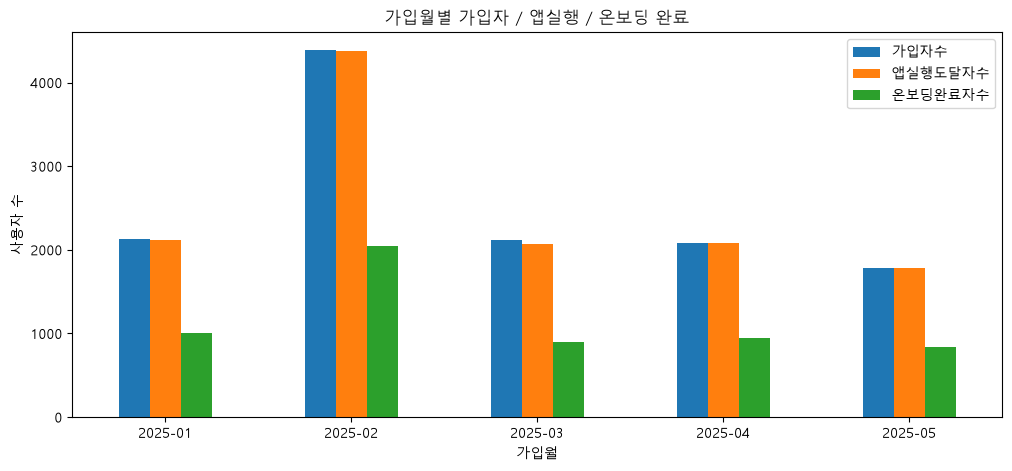

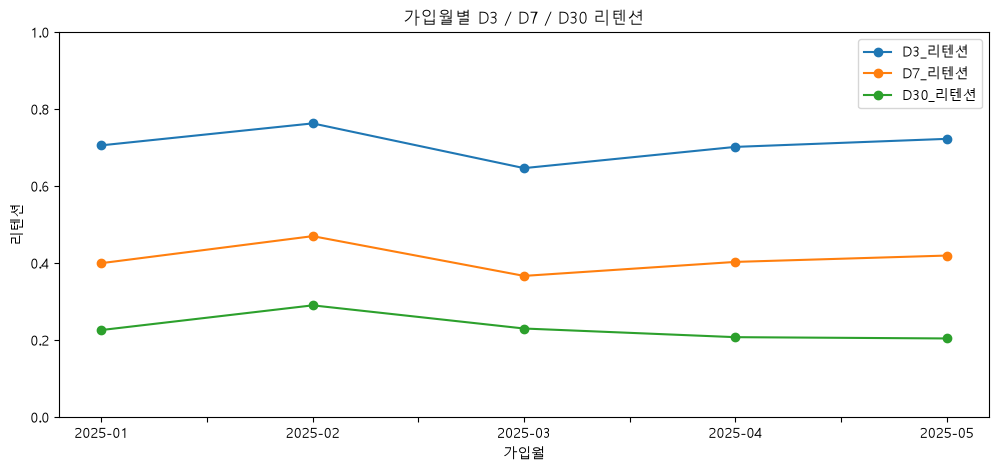

In [75]:
cohort_summary.plot(
    x="가입월",
    y=["가입자수", "앱실행도달자수", "온보딩완료자수"],
    kind="bar",
    figsize=(12, 5),
)
plt.title("가입월별 가입자 / 앱실행 / 온보딩 완료")
plt.xlabel("가입월")
plt.ylabel("사용자 수")
plt.xticks(rotation=0)
plt.show()

cohort_summary.plot(
    x="가입월",
    y=["D3_리텐션", "D7_리텐션", "D30_리텐션"],
    marker="o",
    figsize=(12, 5),
)
plt.title("가입월별 D3 / D7 / D30 리텐션")
plt.xlabel("가입월")
plt.ylabel("리텐션")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

# 저장

In [76]:
# 이벤트 로그 전체는 용량이 커질 수 있으므로 기본값은 False
# 필요하면 True로 바꿔서 저장
SAVE_EVENT_LOG = False

user_profile_output_path = DATA_PROCESSED_DIR / "user_profile_preprocessed_simple.csv"
event_log_output_path = DATA_PROCESSED_DIR / "event_log_preprocessed_simple.csv"
user_level_output_path = DATA_PROCESSED_DIR / "user_level_summary_simple.csv"
cohort_output_path = DATA_PROCESSED_DIR / "cohort_summary_simple.csv"
quality_output_path = DATA_PROCESSED_DIR / "preprocess_quality_summary_simple.csv"
monthly_signup_channel_output_path = DATA_PROCESSED_DIR / "monthly_signup_channel_simple.csv"

user_profile.to_csv(user_profile_output_path, index=False, encoding="utf-8-sig")
user_level_summary.to_csv(user_level_output_path, index=False, encoding="utf-8-sig")
cohort_summary.to_csv(cohort_output_path, index=False, encoding="utf-8-sig")
quality_summary.to_csv(quality_output_path, index=False, encoding="utf-8-sig")
monthly_signup_channel.to_csv(monthly_signup_channel_output_path, index=False, encoding="utf-8-sig")

print("저장 완료")
print(user_profile_output_path)
print(user_level_output_path)
print(cohort_output_path)
print(quality_output_path)
print(monthly_signup_channel_output_path)

저장 완료
C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\user_profile_preprocessed_simple.csv
C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\user_level_summary_simple.csv
C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\cohort_summary_simple.csv
C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\preprocess_quality_summary_simple.csv
C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\processed\monthly_signup_channel_simple.csv
